# Decision Trees

## What Is a Decision Tree?

A Decision Tree learns a sequence of yes/no questions that collectively route every input to a prediction. The core idea is **recursive partitioning**: at each node, find the one question (feature threshold) that best separates the classes, answer it, and repeat on each resulting subset until no further splitting helps.

At each split we ask: *which feature and threshold reduces impurity the most?* Impurity is measured by **Gini**:

$$\text{Gini}(S) = 1 - \sum_k p_k^2$$

A node where everyone survived (or everyone died) has Gini = 0, i.e. it is pure. A 50/50 split has Gini = 0.5, i.e. maximum uncertainty. We greedily pick splits that drive Gini toward zero.

## 1. Setup & Data Download

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import urllib.request, os, sys

sys.path.insert(0, os.path.abspath('../../../src'))
from mlpackage.supervised_learning.decision_tree import DecisionTree
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

CSV_PATH = 'titanic.csv'
if not os.path.exists(CSV_PATH):
    url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv'
    urllib.request.urlretrieve(url, CSV_PATH)
    print('Dataset downloaded.')
else:
    print('Dataset already present.')

Dataset downloaded.


## 2. Data Exploration

In [2]:
df = pd.read_csv(CSV_PATH)
print('Shape:', df.shape)
print('\nSurvival rate:', df['survived'].mean().round(3))
print('\nMissing values:\n', df.isnull().sum()[df.isnull().sum() > 0])
df[['survived','pclass','sex','age','fare','sibsp','parch']].describe()

Shape: (891, 15)

Survival rate: 0.384

Missing values:
 age            177
embarked         2
deck           688
embark_town      2
dtype: int64


,survived,pclass,age,fare,sibsp,parch
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,32.204208,0.523008,0.381594
std,0.486592,0.836071,14.526497,49.693429,1.102743,0.806057
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,7.910400,0.000000,0.000000
50%,0.000000,3.000000,28.000000,14.454200,0.000000,0.000000
75%,1.000000,3.000000,38.000000,31.000000,1.000000,0.000000
max,1.000000,3.000000,80.000000,512.329200,8.000000,6.000000


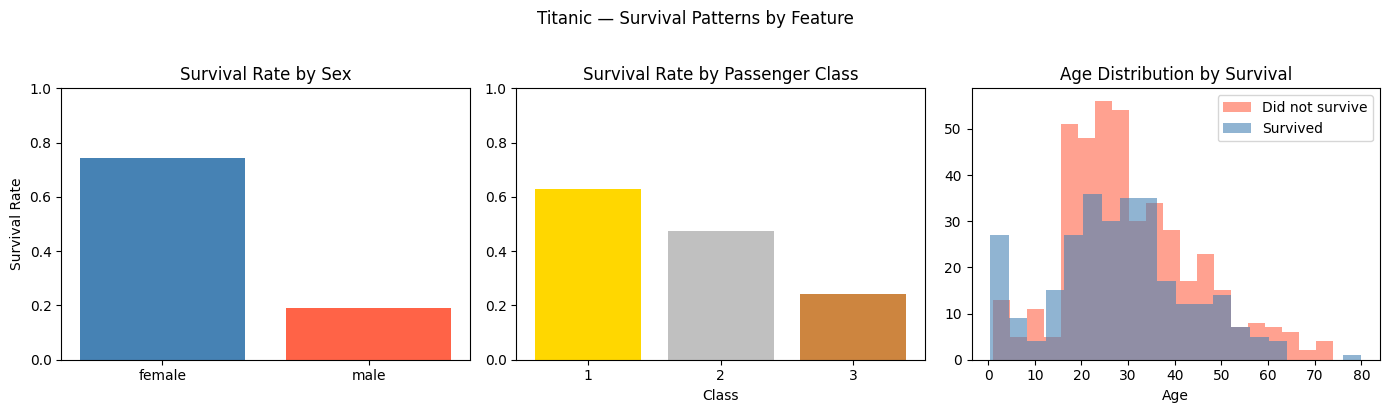

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Survival by sex
surv_sex = df.groupby('sex')['survived'].mean()
axes[0].bar(surv_sex.index, surv_sex.values,
            color=['steelblue','tomato'])
axes[0].set_title('Survival Rate by Sex')
axes[0].set_ylabel('Survival Rate')
axes[0].set_ylim(0, 1)

# Survival by pclass
surv_class = df.groupby('pclass')['survived'].mean()
axes[1].bar(surv_class.index.astype(str), surv_class.values,
            color=['gold','silver','peru'])
axes[1].set_title('Survival Rate by Passenger Class')
axes[1].set_xlabel('Class')
axes[1].set_ylim(0, 1)

# Age distribution by survival
for s, label, color in [(0,'Did not survive','tomato'),(1,'Survived','steelblue')]:
    axes[2].hist(df[df['survived']==s]['age'].dropna(),
                 bins=20, alpha=0.6, label=label, color=color)
axes[2].set_title('Age Distribution by Survival')
axes[2].set_xlabel('Age'); axes[2].legend()

plt.suptitle('Titanic — Survival Patterns by Feature', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

Left plot — Sex: Women survived at ~74%, men at ~19%. Sex is almost certainly the first split the tree will learn since it is the biggest single predictor.

Center plot — Class: 1st class passengers survived at ~63%, 3rd class at ~24%. Wealth determined lifeboat access. The tree will use pclass to refine predictions after the sex split.

Right plot — Age: Children (left tail) have a slightly higher survival rate. The effect is weaker than sex/class, so age appears deeper in the tree.

These patterns are exactly what the Decision Tree will rediscover automatically, and in the same priority order.

## 3. Preprocessing

Decision Trees do not require feature scaling (splits are threshold comparisons, not dot products). We only need to handle missing values and encode the categorical `sex` column.

In [4]:
feature_cols = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare']

df_clean = df[feature_cols + ['survived']].copy()
df_clean['sex'] = (df_clean['sex'] == 'female').astype(int)  # 0=male, 1=female
df_clean['age'] = df_clean['age'].fillna(df_clean['age'].median())
df_clean['fare'] = df_clean['fare'].fillna(df_clean['fare'].median())
df_clean = df_clean.dropna()

X = df_clean[feature_cols].values
y = df_clean['survived'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Survival rate — train: {y_train.mean():.3f}  test: {y_test.mean():.3f}')

Train: (712, 6)  |  Test: (179, 6)
Survival rate — train: 0.383  test: 0.385


## 4. Training

In [5]:
model = DecisionTree(task='classification', max_depth=4)
model.fit(X_train, y_train)

print(f'Train accuracy : {model.score(X_train, y_train):.4f}')
print(f'Test  accuracy : {model.score(X_test, y_test):.4f}')

Train accuracy : 0.8343
Test  accuracy : 0.7765


## 5. Overfitting Analysis — Depth vs Accuracy

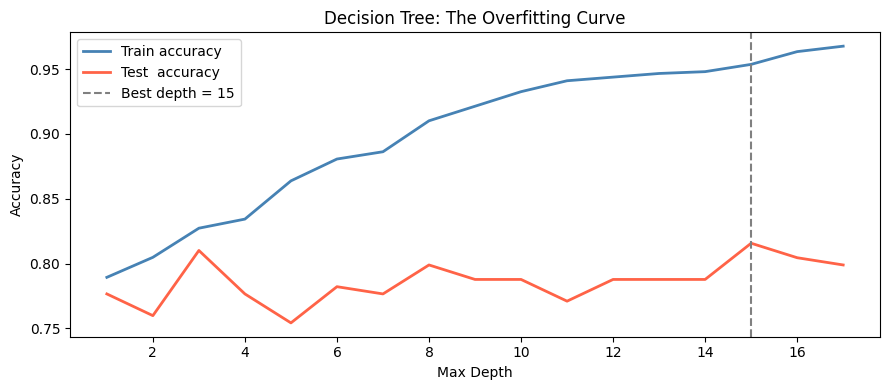

Best depth: 15 (test accuracy = 0.8156)


In [6]:
depths = range(1, 18)
train_accs, test_accs = [], []

for d in depths:
    m = DecisionTree(task='classification', max_depth=d)
    m.fit(X_train, y_train)
    train_accs.append(m.score(X_train, y_train))
    test_accs.append(m.score(X_test, y_test))

best_depth = list(depths)[np.argmax(test_accs)]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(list(depths), train_accs, label='Train accuracy', color='steelblue', linewidth=2)
ax.plot(list(depths), test_accs,  label='Test  accuracy', color='tomato',    linewidth=2)
ax.axvline(best_depth, color='gray', linestyle='--', label=f'Best depth = {best_depth}')
ax.set_xlabel('Max Depth')
ax.set_ylabel('Accuracy')
ax.set_title('Decision Tree: The Overfitting Curve')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Best depth: {best_depth} (test accuracy = {max(test_accs):.4f})')

In the plot above we have:
- Blue line (train): Rises steadily toward 1.0 as the tree grows deeper. At unlimited depth, the tree memorizes every training sample perfectly (train accuracy = 100%). This is overfitting, the model has learned noise specific to the training set, not the general survival pattern.
- Red line (test): Rises initially as the tree learns real patterns, then plateaus or drops as the tree starts memorizing training noise.

The widening gap between blue and red at large depths is the overfitting signature. The model generalizes worse even as it fits the training data better.

The gray dashed line marks the optimal depth: shallow enough to avoid overfitting, deep enough to capture the main survival patterns (sex → class → age).

## 6. Feature Importance

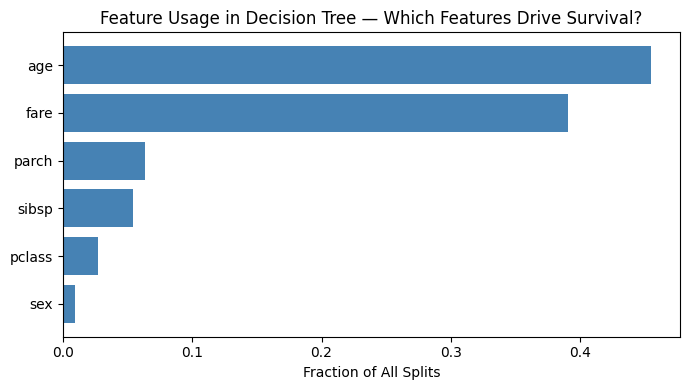

In [7]:
best_model = DecisionTree(task='classification', max_depth=best_depth)
best_model.fit(X_train, y_train)

def count_feature_usage(node, counts):
    if node is None or node.is_leaf:
        return
    counts[node.feature] = counts.get(node.feature, 0) + 1
    count_feature_usage(node.left, counts)
    count_feature_usage(node.right, counts)

counts = {}
count_feature_usage(best_model.root, counts)

importance = np.zeros(len(feature_cols))
for idx, cnt in counts.items():
    importance[idx] = cnt
importance /= importance.sum()

order = np.argsort(importance)
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh([feature_cols[i] for i in order], importance[order],
               color='steelblue')
ax.set_xlabel('Fraction of All Splits')
ax.set_title('Feature Usage in Decision Tree — Which Features Drive Survival?')
plt.tight_layout()
plt.show()

Each bar shows how often that feature was chosen as a split point across all nodes in the tree. A feature that appears in many nodes is highly informative, i.e. the algorithm repeatedly found it useful for separating survivors from non-survivors.

We expect 'sex' and 'pclass' to dominate, which is  consistent with the bar charts in Section 2, and with the historical record of Titanic survival. 'fare' often correlates with class and may also appear frequently.

Features with near-zero importance (e.g., sibsp, parch) contribute little additional information once sex and class are known.

## 7. Evaluation

                 precision    recall  f1-score   support

Did Not Survive       0.84      0.88      0.86       110
       Survived       0.79      0.72      0.76        69

       accuracy                           0.82       179
      macro avg       0.81      0.80      0.81       179
   weighted avg       0.82      0.82      0.82       179



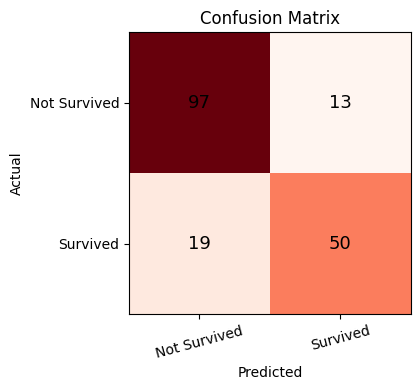

In [13]:
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred,
      target_names=['Did Not Survive', 'Survived']))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(cm, cmap='Reds')
ax.set_xticks([0,1]); ax.set_xticklabels(['Not Survived','Survived'], rotation=15)
ax.set_yticks([0,1]); ax.set_yticklabels(['Not Survived','Survived'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i,j], ha='center', va='center', fontsize=13)
plt.tight_layout(); plt.show()

- Top-left  (True Negatives):  correctly predicted non-survivors
- Bottom-right (True Positives): correctly predicted survivors
- Top-right (False Positives):  predicted survived but actually did not
- Bottom-left (False Negatives): predicted did not survive but actually did

In a survival context, False Negatives (missed survivors) may be considered more costly depending on the application. This motivates examining precision/recall separately rather than relying on accuracy alone.

## 8. Key Takeaways

- The **overfitting curve** is the central lesson: train accuracy climbs to 1.0 with unlimited depth while test accuracy peaks early and then drops. The model memorizes noise once it goes deeper than the real signal.
- **Feature importance** confirms the known historical pattern: sex is the dominant predictor, followed by class and fare. The tree discovers this without being told.
- Decision Trees need **no feature scaling**, splits compare feature values to thresholds, which is scale-invariant.

## Why Decision Trees?

Decision Trees are uniquely well-suited to the Titanic dataset because:

- **The learned rules match real-world knowledge**. "Women and children first" is a known historical survival heuristic, and the tree discovers this automatically from data. You can read the tree's rules in plain English and verify they make sense.
- **Mixed feature types**: age (continuous), pclass (ordinal), sex (categorical after encoding), fare (continuous). Decision Trees handle all of these natively without scaling.
- **Missing values and noise** give us practice with realistic preprocessing while keeping the core modeling task simple (binary outcome).
- The overfitting analysis (depth vs accuracy curve) is especially clear: a tree of depth 1 learns almost nothing, a tree of depth 2–3 learns the main survival patterns, and unlimited depth memorizes noise.